In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_customers = pd.read_csv("olist_customers_dataset (1).csv")
df_geolocation = pd.read_csv("olist_geolocation_dataset_limpio_completo.csv")

In [ ]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
df_customers.shape

(99441, 5)

In [ ]:
df_customers.dtypes

,0
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object


In [ ]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
df_customers.isnull().sum().sort_values()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
#vemos si hay toda una fila duplicada
df_customers.duplicated().sum()

np.int64(0)

In [ ]:
#vemos si en los id de customers hay duplicados
df_customers.customer_id.duplicated().sum()

np.int64(0)

In [ ]:
#vemos si en los id unicos de customers hay duplicados
df_customers.customer_unique_id.duplicated().sum()

np.int64(3345)

In [ ]:
df_customers.customer_unique_id.duplicated().value_counts()

,count
customer_unique_id,
False,96096
True,3345


In [ ]:
#vemos cuales son los duplicados
df_customers[df_customers.duplicated(['customer_unique_id'])]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
679,c57b4b6f3719475543b721e720a526ad,b6c083700ca8c135ba9f0f132930d4e8,8686,suzano,SP
1463,9f6f3da49e2d46e3a7529f5e3c25ecce,a40096fc0a3862e9e12bc55b5f8e6ab2,20561,rio de janeiro,RJ
1607,299f7b5125c8fbe1761a1b320c34fc7d,b8b3c435a58aebd788a477bed8342910,95585,arroio do sal,RS
2811,226d59f9f4b98e228b689eea45d03a6d,66980c3775537536f77b434d74e520f5,30290,belo horizonte,MG
3198,b1253701171dfb298f52a221f824e45b,788313d21c3507fe890921f6e17aa679,11070,santos,SP
...,...,...,...,...,...
99324,5b46a0d983eec8c97363bea78d4a69dd,8bab3162259edfaadd1ea2e1fe7f58dc,31565,belo horizonte,MG
99327,c1affa46f9f3b514555259049a0307b9,12ab9334b1240d6d037f2b0102a49571,38050,uberaba,MG
99336,ebf46ff530343a129926adc1f831dea4,0ee57f62666561b72f2ceacad0230cbf,9530,sao caetano do sul,SP
99353,282fbce48e4d2077aad602dd125c9225,0ceb502fc33a2ad327b08288c5310e2e,29134,viana,ES


In [ ]:
#array con los valores duplicados
df_customers[df_customers.customer_unique_id.duplicated()].customer_unique_id.values

array(['b6c083700ca8c135ba9f0f132930d4e8',
       'a40096fc0a3862e9e12bc55b5f8e6ab2',
       'b8b3c435a58aebd788a477bed8342910', ...,
       '0ee57f62666561b72f2ceacad0230cbf',
       '0ceb502fc33a2ad327b08288c5310e2e',
       '5cbfdb85ec130898108b32c50d619c39'], dtype=object)

In [ ]:
#contamos las veces que se repiten las ciudades
df_customers.customer_city.value_counts()

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
olhos d'agua,1
pacotuba,1
sao sebastiao do paraiba,1


In [ ]:
#Cambiamos nombres de las columnas para normalizar el data set
df_cambio_columnas = df_customers.rename(columns={
    'customer_id': 'ID_CLIENTE',
    'customer_unique_id': 'ID_UNICO_CLIENTE',
    'customer_zip_code_prefix': 'CODIGO POSTAL',
    'customer_city': 'CIUDAD',
    'customer_state': 'ESTADO'
})
print(df_cambio_columnas)

                             ID_CLIENTE                  ID_UNICO_CLIENTE  \
0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                 ...                               ...   
99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

       CODIGO POSTAL                 CIUDAD ESTADO  
0              14409  

In [ ]:
# Eliminar columnas 'customer_city' y 'customer_state'
df_customers_clean = df_customers.drop(columns=['customer_city', 'customer_state'])

# Hacer merge con el dataset de geolocalización
df_merge = pd.merge(
    df_customers_clean,
    df_geolocation,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'  # o 'inner' si querés solo los que tienen coincidencia
)


<ipython-input-33-ad032893e707>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  p = sns.countplot(x='customer_state',data=df_customers, palette="Spectral")


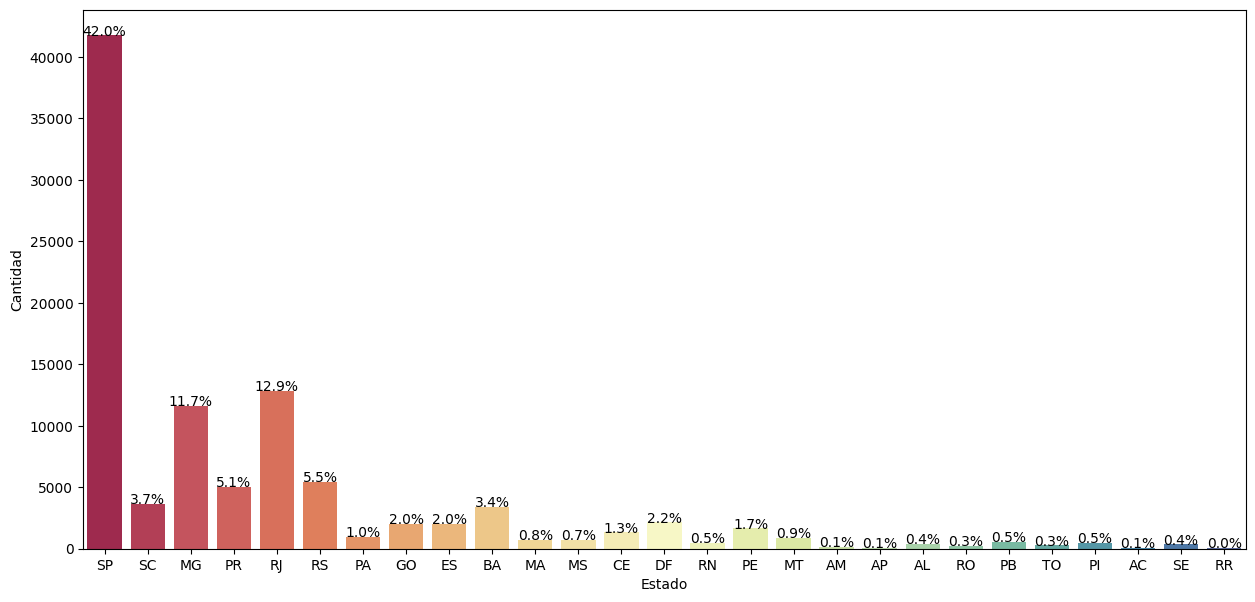

In [ ]:
#graficamos la cantidad de customers por estado
plt.figure(figsize = (15,7))
p = sns.countplot(x='customer_state',data=df_customers, palette="Spectral")
p.set( xlabel = "Estado", ylabel = "Cantidad")
n = len(df_customers)
for k in p.patches:
    height = k.get_height()
    p.text(k.get_x() + k.get_width()/2., height, '{:.1%}'.format(height/n), ha="center")

In [ ]:
df_customers_clean.to_csv("customers_limpio.csv", index=False)


In [ ]:
df_cambio_columnas.dtypes

,0
ID_CLIENTE,object
ID_UNICO_CLIENTE,object
CODIGO POSTAL,int64
CIUDAD,object
ESTADO,object
